In [27]:
import pandas as pd
import numpy as np
import random
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")

<h2>Reading Data</h2>

In [28]:
df = pd.read_csv('./ml-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
df.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [29]:
columns = [
    'movie_id', 'title', 'release_date', 'video_release_date', 'IMDb_URL',
    'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]
movie =  pd.read_csv(
    './ml-100k/u.item', 
    sep='|', 
    encoding='latin-1',  # For special characters in movie titles
    names=columns,
)
movie = movie.drop(columns="video_release_date") # Too many null values inside this column
movie.head()

,movie_id,title,release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children's,Comedy,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [30]:
users = pd.read_csv('./ml-100k/u.user', sep='|', names=['user_id', 'age', 'gender', 'occupation', 'zip_code'])
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [31]:
rating_counts = df['item_id'].value_counts()
top_50_percent_count = int(len(rating_counts) * 0.50)
top_50_percent_movies = rating_counts.head(top_50_percent_count).index.tolist()
subsampled_u_item = movie[movie['movie_id'].isin(top_50_percent_movies)]
subsampled_data = df[df['item_id'].isin(top_50_percent_movies)]
subsampled_user_ids = subsampled_data['user_id']
subsampled_u_user = users[users['user_id'].isin(subsampled_user_ids)]
df = subsampled_data
movies = subsampled_u_item 
users = subsampled_u_user

<h2>Preprocess data</h2>

In [32]:
# Make the index zero-based
df['user_id'] -= 1
df['item_id'] -= 1
users['user_id'] -= 1
movie['movie_id'] -= 1

In [33]:
# Preprocess user features: encode gender as 0/1 and create one-hot encoding for occupation
users['gender'] = users['gender'].map({'M': 0, 'F': 1})
users = pd.get_dummies(users, columns=['occupation'])

In [34]:
# Extract relevant movie features: keep genre flags
movie_features = movie[['movie_id'] + list(movie.columns[5:])]
# Merge u_data with user and movie features
data_with_features = df.merge(users, on='user_id').merge(movie_features, left_on='item_id', right_on='movie_id')

In [35]:
data_with_features = data_with_features.drop(columns='zip_code')

In [36]:
data_with_features['reward'] = np.where(data_with_features['rating'] >= 3, 1, 0)

In [37]:
data_with_features.columns

Index(['user_id', 'item_id', 'rating', 'timestamp', 'age', 'gender',
       'occupation_administrator', 'occupation_artist', 'occupation_doctor',
       'occupation_educator', 'occupation_engineer',
       'occupation_entertainment', 'occupation_executive',
       'occupation_healthcare', 'occupation_homemaker', 'occupation_lawyer',
       'occupation_librarian', 'occupation_marketing', 'occupation_none',
       'occupation_other', 'occupation_programmer', 'occupation_retired',
       'occupation_salesman', 'occupation_scientist', 'occupation_student',
       'occupation_technician', 'occupation_writer', 'movie_id', 'Action',
       'Adventure', 'Animation', 'Children's', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
       'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'reward'],
      dtype='object')

In [38]:
# Map each unique item_id to a continuous index
unique_arms = sorted(data_with_features['item_id'].unique())
arm_mapping = {arm: idx for idx, arm in enumerate(unique_arms)}

<h2>Introduce the Bandit Algo</h2>

In [39]:
class ContextualEpsilonDecay:
    def __init__(self, n_arms, decay_rate=0.99, min_epsilon=0.01): 
        self.n_arms = n_arms
        self.decay_rate = decay_rate
        self.min_epsilon = min_epsilon
        self.context_counts = {}  # Store counts for each arm-context pair
        self.context_values = {}  # Store values for each arm-context pair

    def initialize_context(self, context):
        # Initialize counts and values for a new context
        if context not in self.context_counts:
            self.context_counts[context] = [0 for _ in range(self.n_arms)]
            self.context_values[context] = [0.0 for _ in range(self.n_arms)]

    def select_arm(self, context, features):
        if context not in self.context_counts:
            self.initialize_context(context)

        # Calculate decayed epsilon for this context
        counts = self.context_counts[context]
        average_counts = sum(counts) / len(counts) if sum(counts) > 0 else 0
        epsilon = max(self.min_epsilon, self.decay_rate / (average_counts + 1))

        # Calculate scores for each arm based on the stored values
        scores = np.array([self.context_values[context][arm] for arm in range(self.n_arms)])
        
        # Select the arm based on epsilon-greedy strategy
        if random.random() > epsilon:
            return np.argmax(scores)  # Exploit: choose the arm with the highest score
        else:
            return random.randrange(self.n_arms)

    def update(self, context, chosen_arm, reward):
        # Ensure the context is initialized
        if context not in self.context_counts:
            self.initialize_context(context)

        # Update counts and values for the chosen arm in the given context
        counts = self.context_counts[context]
        values = self.context_values[context]
        
        counts[chosen_arm] += 1
        n = counts[chosen_arm]
        value = values[chosen_arm]
        new_value = ((n - 1) / float(n)) * value + (1 / float(n)) * reward
        values[chosen_arm] = new_value


<h2>Simulator</h2>

In [40]:
# Define good arms and good bias based on the data
movie_avg_ratings = df.groupby('item_id')['rating'].mean()
good_arms = movie_avg_ratings[movie_avg_ratings > 4.3].index.tolist()
mapped_good_arms  = [arm_mapping[arm] for arm in good_arms]
overall_avg_rating = df['rating'].mean()
good_bias = movie_avg_ratings[good_arms].mean() - overall_avg_rating

In [41]:
good_arms

[11, 49, 63, 113, 168, 177, 317, 407, 482, 512, 602]

In [42]:
class Simulator:
    def __init__(self, n_trials, n_arms, n_features, good_arms, good_bias):
        self.n_trials = n_trials  # Number of trials, each representing a user interaction
        self.n_arms = n_arms  # Number of arms
        self.n_features = n_features  # Number of features for each context
        self.good_arms = good_arms  # List of indices of the "good" arms
        self.good_bias = good_bias  # Bias for the good arms to simulate their appeal
        self.X = []  # Context matrix for each trial (generated later)
        self.true_theta = None  # True theta values for reward generation

    def simulate_context_matrix(self):
        """Generate a context matrix for each trial and arm, with different features for each arm."""
        self.X = np.array([
            [np.random.uniform(low=0, high=1, size=self.n_features) for _ in range(self.n_arms)]
            for _ in range(self.n_trials)
        ])
        return self.X

    def simulate_theta(self):
        """Simulate true theta values for each arm, adding bias for good arms."""
        true_theta = np.array([np.random.normal(loc=0, scale=1/4, size=self.n_features) for _ in range(self.n_arms)])
        if len(self.good_arms) > 0:
            true_theta[self.good_arms] += self.good_bias
        self.true_theta = true_theta
        return self.true_theta

    def initialization(self):
        """Initialize the context matrix and true theta values."""
        self.simulate_context_matrix()
        self.simulate_theta()

    def simulate_one_trial(self, bandit):
        """Simulate one trial by selecting an arm based on current context and updating the bandit."""
        total_reward = 0
        for t in range(self.n_trials):
            # Select the context and feature vector for the current trial
            context_features = self.X[t]  # Features for each arm in the current trial

            # Let the bandit choose an arm based on the current context
            chosen_arm = bandit.select_arm(t, context_features)

            # Generate a reward based on the chosen arm and context
            reward = simulate_one_time_reward(chosen_arm, context_features[chosen_arm], self.true_theta[chosen_arm])

            # Update the bandit with the reward
            bandit.update(t, chosen_arm, reward)

            # Accumulate reward for evaluation purposes
            total_reward += reward
        return total_reward

# Function to predict reward given an arm, context feature vector x, and theta values
def simulate_one_time_reward(arm, x, theta, scale_noise=0.01):
    """Calculate reward based on the linear sum of x with some added noise."""
    signal = np.dot(theta, x)
    noise = np.random.normal(scale=scale_noise)
    return signal + noise


In [43]:
n_arms = movie['movie_id'].nunique()
n_features = data_with_features.shape[1] - 4  # exclude 'user_id', 'item_id', 'rating', 'timestamp', 'reward'
bandit = ContextualEpsilonDecay(n_arms=n_arms)

In [44]:
# Parameters
my_n_trials = 500
my_n_arms = n_arms  # Example value, set to match the number of arms
my_n_features = n_features 
good_bias = 1

# Initialize simulator and epsilon decay bandit
my_simulation = Simulator(my_n_trials, my_n_arms, my_n_features, good_arms, good_bias)
my_simulation.initialization()

# Initialize the ContextualEpsilonDecay bandit
decay_rate = 0.99
min_epsilon = 0.01
my_epsilon_decay_bandit = ContextualEpsilonDecay(n_arms=my_n_arms, decay_rate=decay_rate, min_epsilon=min_epsilon)

# Track histories
values_history = np.empty(shape=(my_n_trials, my_n_arms))  # Track arm values over time
arm_selection_history = np.empty(my_n_trials)
reward_history = np.empty(my_n_trials)

# Run simulation over trials
for t in range(my_n_trials):
    # Select an arm based on the current context
    context_features = my_simulation.X[t]  # Features for each arm in the current trial
    selected_arm = my_epsilon_decay_bandit.select_arm(t, context_features)

    # Observe reward based on selected arm
    reward_observed = simulate_one_time_reward(
        arm=selected_arm, 
        x=context_features[selected_arm], 
        theta=my_simulation.true_theta[selected_arm]
    )
    
    # Update the bandit with observed reward
    my_epsilon_decay_bandit.update(t, selected_arm, reward_observed)

    # Store results for analysis
    values_history[t] = my_epsilon_decay_bandit.context_values[t]
    arm_selection_history[t] = selected_arm
    reward_history[t] = reward_observed

# Compile results
results = {
    "values_history": values_history, 
    "arm_selection_history": arm_selection_history, 
    "reward_history": reward_history
}


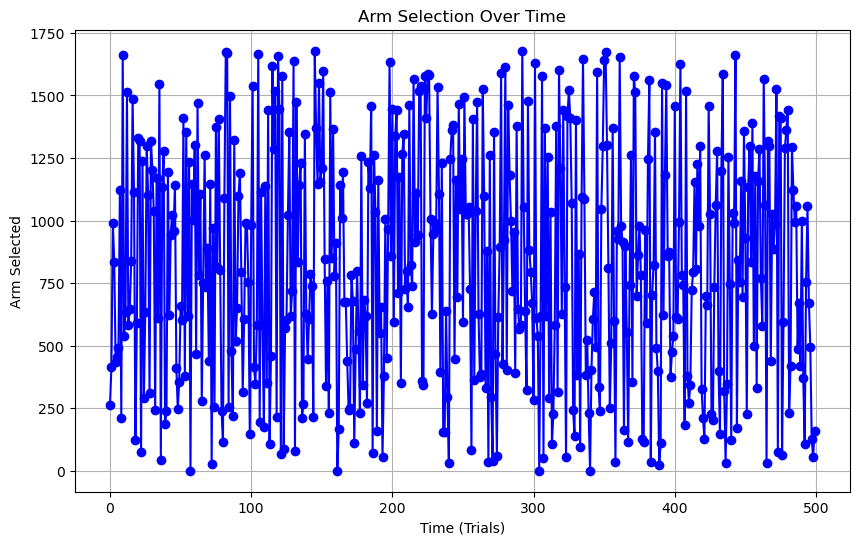

In [45]:
import matplotlib.pyplot as plt

# Plot arm selection over time
plt.figure(figsize=(10, 6))
plt.plot(arm_selection_history, marker='o', linestyle='-', color='b')
plt.title('Arm Selection Over Time')
plt.xlabel('Time (Trials)')
plt.ylabel('Arm Selected')
plt.grid(True)
plt.show()

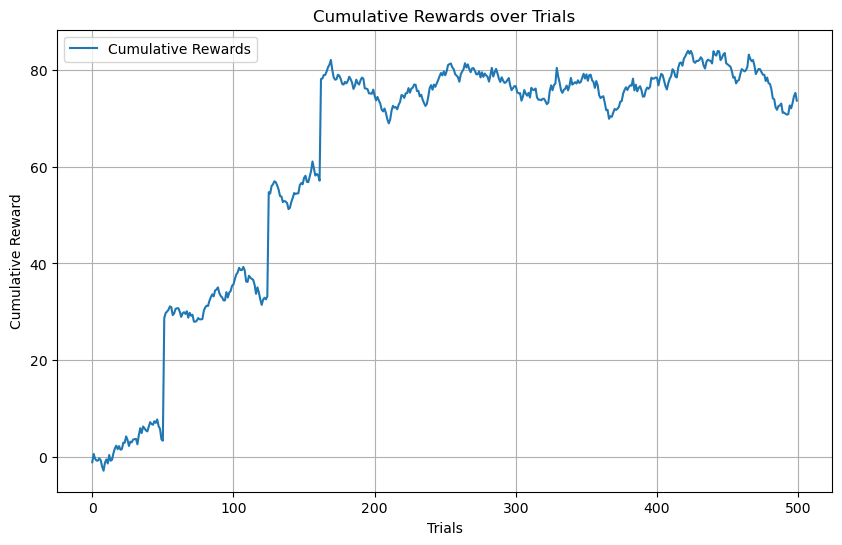

In [46]:
cumulative_rewards = np.cumsum(reward_history)

# Plot cumulative rewards over trials
plt.figure(figsize=(10, 6))
plt.plot(cumulative_rewards, label="Cumulative Rewards")
plt.xlabel("Trials")
plt.ylabel("Cumulative Reward")
plt.title("Cumulative Rewards over Trials")
plt.legend()
plt.grid(True)
plt.show()

<h2>Attempting using replay</h2>

In [ ]:
context_columns = ['user_id', 'item_id', 'timestamp', 'age', 'gender', 'occupation_administrator', 'occupation_artist', 
    'occupation_doctor', 'occupation_educator', 'occupation_engineer', 'occupation_entertainment', 
    'occupation_executive', 'occupation_healthcare', 'occupation_homemaker', 'occupation_lawyer', 
    'occupation_librarian', 'occupation_marketing', 'occupation_none', 'occupation_other', 'occupation_programmer', 
    'occupation_retired', 'occupation_salesman', 'occupation_scientist', 'occupation_student', 
    'occupation_technician', 'occupation_writer']
features_columns = ['movie_id', 'Action', 'Adventure', 'Animation', "Children's", 
    'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 
    'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


my_n_features = n_features
decay_rate = 0.99
min_epsilon = 0.01
# Initialize the algorithm
algorithm = ContextualEpsilonDecay(n_arms=n_arms, decay_rate=0.99, min_epsilon=0.01)

# Initialize an empty list to track evaluation results
evaluation = []
match_records = []
average_rewards = []

cumulative_rewards = 0
match_count = 0
#evaluation.append({
#    'time_step': 0,
#    'chosen_arm': None,  # or -1
#    'reward': 0,
#    'cumulative_rewards': 0
#})

# Iterate over each row in the DataFrame
for i, row in data_with_features.iterrows():
    # Create the context as a tuple of the relevant features
    context = tuple(row[data_with_features.columns.get_loc(col)] for col in context_columns)
    features = tuple(row[data_with_features.columns.get_loc(col)] for col in features_columns)
    
    # Initialize context in the algorithm
    algorithm.initialize_context(context)

    # Get a recommendation (select an arm) from the algorithm based on the context
    selected_arm = algorithm.select_arm(context,features)
    
    # Get the actual arm and reward from the data
    actual_arm = row['item_id'] - 1  # Adjust if `item_id` is not zero-indexed
    reward = row['reward']  # Assuming 'reward' is the reward column

    # Check if the recommendation matches the actual arm
    if selected_arm == actual_arm:
        has_match = True
        match_count+=1
        cumulative_rewards += reward 
        evaluation.append({
            'time_step': i + 1,# Time step based on the loop iteration
            'chosen_arm': selected_arm,
            'reward': reward, 
            'cumulative_rewards': cumulative_rewards,
        })
        
        # Update the algorithm with the observed reward
        algorithm.update(context, selected_arm, reward)

     # Calculate the cumulative match rate at this time step
    match_rate = match_count / (i + 1)
    match_records.append({
        'time_step': i + 1,
        'match_rate': match_rate
    })
    average_reward = cumulative_rewards / (i + 1)
    average_rewards.append(average_reward)

# Convert evaluation results to a DataFrame for analysis
evaluation_df = pd.DataFrame(evaluation)
match_rate_df = pd.DataFrame(match_records)
# Calculate loss rate and average loss over time from the loss_df
#loss_rate_df = loss_df.groupby('time_step').size().reset_index(name='loss_count')
#loss_rate_df['loss_rate'] = loss_rate_df['loss_count'] / len(data_with_features)
#average_loss_df = loss_df.groupby('time_step')['loss'].mean().reset_index(name='average_loss')
#evaluation_df.head()
total_steps = len(data_with_features)
print(f"Total Matches: {match_count} out of {total_steps} steps")
if match_count == 0:
    print("The algorithm never selected the correct arm. Check arm selection logic or data alignment.")



KeyboardInterrupt: 

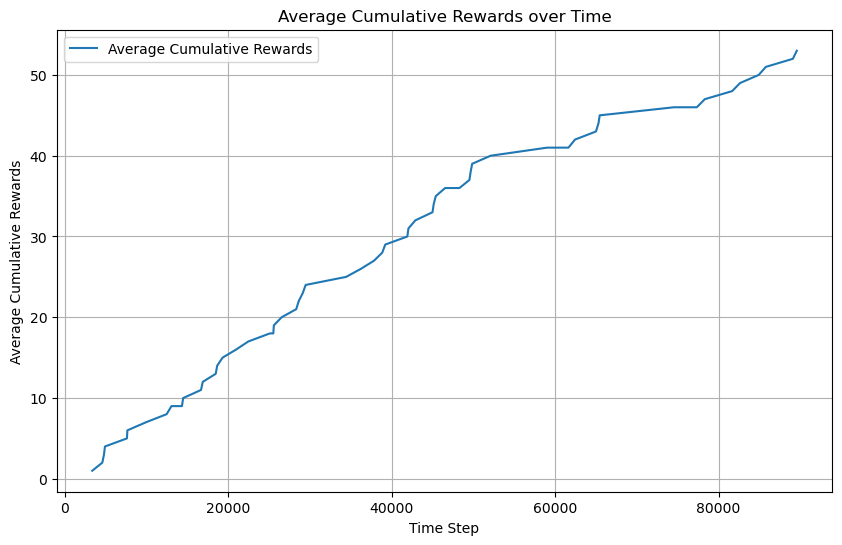

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(evaluation_df['time_step'], evaluation_df['cumulative_rewards'], label='Average Cumulative Rewards')
plt.xlabel('Time Step')
plt.ylabel('Average Cumulative Rewards')
plt.title('Average Cumulative Rewards over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
evaluation_df.to_csv('evaluation_df.csv', index=False)

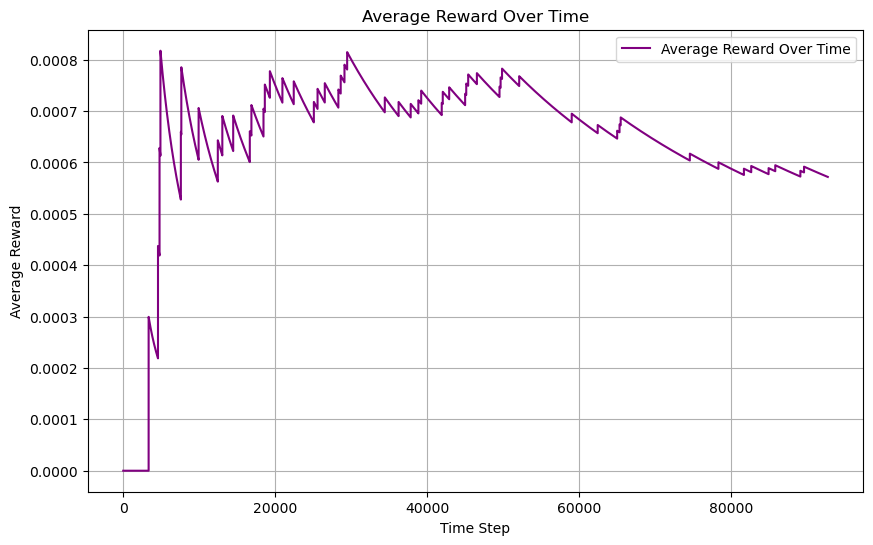

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(average_rewards) + 1), average_rewards, label='Average Reward Over Time', color='purple')
plt.xlabel('Time Step')
plt.ylabel('Average Reward')
plt.title('Average Reward Over Time')
plt.legend()
plt.grid(True)
plt.show() #seems liek the same thing